Model Comparison: RF vs XGBoost vs MLP

Overview plots comparing test performance across models, feature sets, and split strategies.

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

BASE = '/Users/isabellamueller-vogt/Library/Mobile Documents/com~apple~CloudDocs/05 - ETH/06 - FS 2026/04 - Digital Chemistry/dc_project'
OUT  = f'{BASE}/results/comparison'

# ── Color palette (from design spec) ────────────────────────────────────────
MODEL_COLORS  = {'RF': '#1E3A5F', 'XGB': '#2E7D7D', 'MLP': '#5B3D8C'}
SPLIT_COLORS  = {'random': '#4F6F8F', 'topology': '#6FA8C8', 'metal': '#B49AD6'}

# ── Sequential R² colormap  (spec: 0.4→#CFE0DC … 1.0→#0E3B39) ──────────────
CMAP_R2 = LinearSegmentedColormap.from_list(
    'r2_seq',
    [(0.00, '#E5F3F0'),   # extrapolated light for R² < 0.4
     (0.40, '#CFE0DC'),
     (0.55, '#8FBBB3'),
     (0.70, '#4F908A'),
     (0.85, '#246763'),
     (1.00, '#0E3B39')],
    N=256
)

# ── Ordering / labels ───────────────────────────────────────────────────────
MODEL_ORDER        = ['RF', 'XGB', 'MLP']
FULL_FEATURE_ORDER = ['baseline', 'geo_decorr', 'geo_all',
                      'rac_decorr', 'rac_all',
                      'combined_decorr', 'combined_all']
# Bar plots use 'all' variants; baseline shown only as reference lines
FEATURE_ORDER  = ['geo_all', 'rac_all', 'combined_all']
FEATURE_LABELS = ['Geo', 'RAC', 'Combined']

SPLIT_ORDER   = ['random', 'topology', 'metal']
SPLIT_LABELS  = {
    'random':   'Random 90/10',
    'topology': 'Topology-strat.',
    'metal':    'Metal-node-strat.',
}

# ── Descriptor-set hatch encoding ───────────────────────────────────────────
DESCRIPTOR_CAT = {'geo_all': 'geo', 'rac_all': 'rac', 'combined_all': 'combined'}
HATCH_MAP      = {'geo': '//', 'rac': '////', 'combined': ''}

# ── Bar geometry (shared by plots 1 & 2) ────────────────────────────────────
N_FEAT  = len(FEATURE_ORDER)
N_MOD   = len(MODEL_ORDER)
GROUP_W = 0.7
BAR_W   = GROUP_W / N_MOD
X       = np.arange(N_FEAT)

sns.set_theme(style='whitegrid', font='sans-serif')
plt.rcParams.update({'figure.dpi': 150, 'savefig.dpi': 300})

In [56]:
# ── Load & merge ─────────────────────────────────────────────────────────────
COLS = ['feature_set', 'split', 'n_features', 'best_cv_RMSE', 'test_RMSE', 'test_MAE', 'test_R2']

xgb = pd.read_csv(f'{BASE}/results/xgb/xgb_summary.csv')
xgb = xgb[xgb['method'] == 'optuna'][COLS].copy()
xgb['model'] = 'XGB'

rf = pd.read_csv(f'{BASE}/results/rf/rf_summary.csv')
rf = rf[rf['method'] == 'optuna'][COLS].copy()
rf['model'] = 'RF'

mlp = pd.read_excel(f'{BASE}/results/mlp/mlp_summary.csv')
mlp['model'] = 'MLP'

df = pd.concat([xgb, rf, mlp], ignore_index=True)
df['feature_set'] = pd.Categorical(df['feature_set'], categories=FULL_FEATURE_ORDER, ordered=True)
df['model']       = pd.Categorical(df['model'],       categories=MODEL_ORDER,         ordered=True)
df['split']       = pd.Categorical(df['split'],       categories=SPLIT_ORDER,         ordered=True)

print(df.groupby(['model', 'split'], observed=True).size().unstack())

split  random  topology  metal
model                         
RF          7         7      7
XGB         7         7      7
MLP         7         7      7


All Features vs Decorrelated — Which Variant Generalises Better?

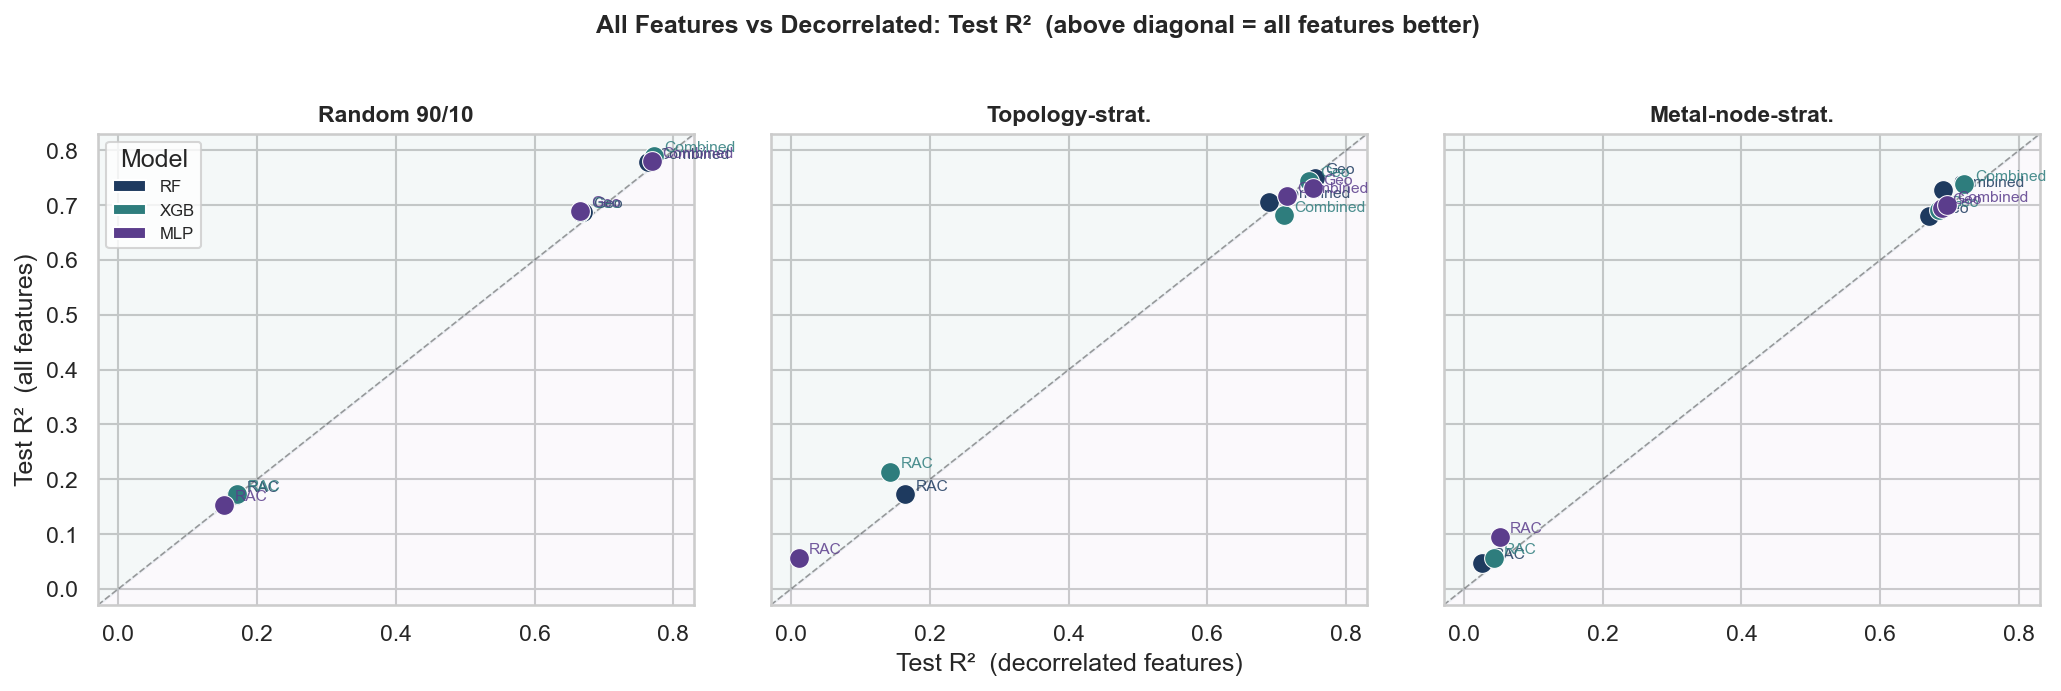

Subsequent plots use feature sets: ['geo_all', 'rac_all', 'combined_all']


In [57]:
# ── Build pairwise comparison: decorr vs all ─────────────────────────────────
DESC_PAIRS = {
    'Geo':      ('geo_decorr',      'geo_all'),
    'RAC':      ('rac_decorr',      'rac_all'),
    'Combined': ('combined_decorr', 'combined_all'),
}

records = []
for desc, (feat_d, feat_a) in DESC_PAIRS.items():
    for model in MODEL_ORDER:
        for split in SPLIT_ORDER:
            row_d = df[(df['feature_set']==feat_d) & (df['model']==model) & (df['split']==split)]
            row_a = df[(df['feature_set']==feat_a) & (df['model']==model) & (df['split']==split)]
            if not row_d.empty and not row_a.empty:
                records.append({'descriptor': desc, 'model': model, 'split': split,
                                'R2_decorr': row_d['test_R2'].values[0],
                                'R2_all':    row_a['test_R2'].values[0]})
comp = pd.DataFrame(records)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True, sharex=True)
fig.suptitle('All Features vs Decorrelated: Test R²  (above diagonal = all features better)',
             fontsize=12, fontweight='bold', y=1.02)

vals = comp[['R2_decorr', 'R2_all']].values.ravel()
lo, hi = vals.min() - 0.04, vals.max() + 0.04

for ax, split in zip(axes, SPLIT_ORDER):
    sub = comp[comp['split'] == split]

    ax.fill_between([lo, hi], [lo, hi], [hi, hi], color='#2E7D7D', alpha=0.05)
    ax.fill_between([lo, hi], [lo, lo], [lo, hi], color='#B49AD6', alpha=0.05)

    for model in MODEL_ORDER:
        m = sub[sub['model'] == model]
        ax.scatter(m['R2_decorr'], m['R2_all'],
                   color=MODEL_COLORS[model], s=90,
                   edgecolors='white', linewidths=0.5, zorder=3)
        for _, row in m.iterrows():
            ax.annotate(row['descriptor'],
                        (row['R2_decorr'], row['R2_all']),
                        fontsize=7.5, color=MODEL_COLORS[model], alpha=0.85,
                        xytext=(5, 2), textcoords='offset points')

    ax.plot([lo, hi], [lo, hi], 'k--', lw=0.8, alpha=0.4)
    ax.set_title(SPLIT_LABELS[split], fontsize=11, fontweight='bold')
    ax.set_xlabel('Test R²  (decorrelated features)' if ax is axes[1] else '')
    ax.set_ylabel('Test R²  (all features)' if ax is axes[0] else '')
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)

    if ax is axes[0]:
        handles = [mpatches.Patch(facecolor=MODEL_COLORS[m], edgecolor='white', label=m)
                   for m in MODEL_ORDER]
        ax.legend(handles=handles, title='Model', fontsize=8, framealpha=0.8)

plt.tight_layout()
plt.savefig(f'{OUT}/model_comparison_all_vs_decorr.png', bbox_inches='tight')
plt.show()

# ── Store baseline reference values before filtering ─────────────────────────
baseline_r2   = df[df['feature_set'] == 'baseline'].set_index(['model', 'split'])['test_R2']
baseline_rmse = df[df['feature_set'] == 'baseline'].set_index(['model', 'split'])['test_RMSE']

# ── Restrict df to 'all' variants (no baseline bars in subsequent plots) ──────
df = df[df['feature_set'].isin(FEATURE_ORDER)].copy()
df['feature_set'] = pd.Categorical(df['feature_set'], categories=FEATURE_ORDER, ordered=True)
print(f'Subsequent plots use feature sets: {FEATURE_ORDER}')

Test R^2 for all feature sets by split

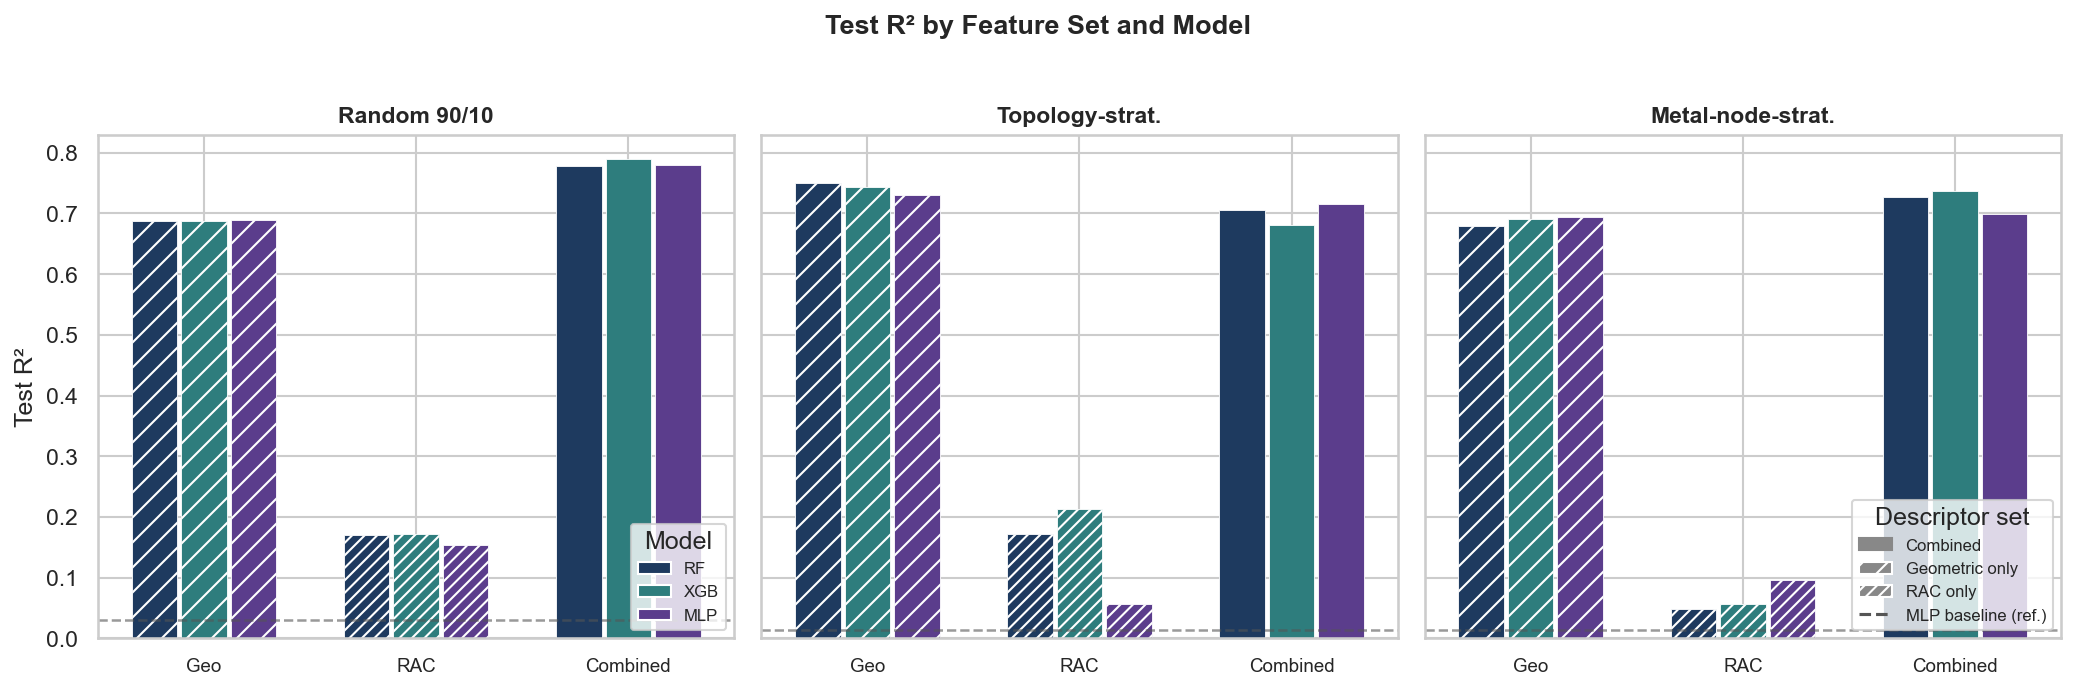

In [58]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)
fig.suptitle('Test R² by Feature Set and Model', fontsize=13, fontweight='bold', y=1.02)

for ax, split in zip(axes, SPLIT_ORDER):
    lookup = df[df['split'] == split].set_index(['feature_set', 'model'])['test_R2']

    for i, model in enumerate(MODEL_ORDER):
        offsets = X + (i - (N_MOD - 1) / 2) * BAR_W
        for k, feat in enumerate(FEATURE_ORDER):
            val   = lookup.get((feat, model), np.nan)
            hatch = HATCH_MAP[DESCRIPTOR_CAT[feat]]
            ax.bar(offsets[k], val, width=BAR_W * 0.92,
                   facecolor=MODEL_COLORS[model], hatch=hatch,
                   edgecolor='white', linewidth=0.4)

    # MLP baseline as single reference line
    bval = baseline_r2.get(('MLP', split), np.nan)
    if not np.isnan(bval):
        ax.axhline(bval, color='#555555', lw=1.2, ls='--', alpha=0.6)

    ax.set_title(SPLIT_LABELS[split], fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Test R²' if ax is axes[0] else '')
    ax.set_xticks(X)
    ax.set_xticklabels(FEATURE_LABELS, fontsize=9)
    ax.set_xlim(-0.5, N_FEAT - 0.5)

model_patches = [mpatches.Patch(facecolor=MODEL_COLORS[m], edgecolor='white', label=m)
                 for m in MODEL_ORDER]
desc_patches  = [
    mpatches.Patch(facecolor='#888', hatch='',     edgecolor='#888', label='Combined'),
    mpatches.Patch(facecolor='#888', hatch='//',   edgecolor='white', label='Geometric only'),
    mpatches.Patch(facecolor='#888', hatch='////', edgecolor='white', label='RAC only'),
    plt.Line2D([0], [0], color='#555555', lw=1.5, ls='--', label='MLP baseline (ref.)'),
]
axes[0].legend(handles=model_patches, title='Model',          loc='lower right', framealpha=0.8, fontsize=8)
axes[2].legend(handles=desc_patches,  title='Descriptor set', loc='lower right', framealpha=0.8, fontsize=8)

plt.tight_layout()
plt.savefig(f'{OUT}/model_comparison_r2.png', bbox_inches='tight')
plt.show()

Test RMSE for all feature sets by split

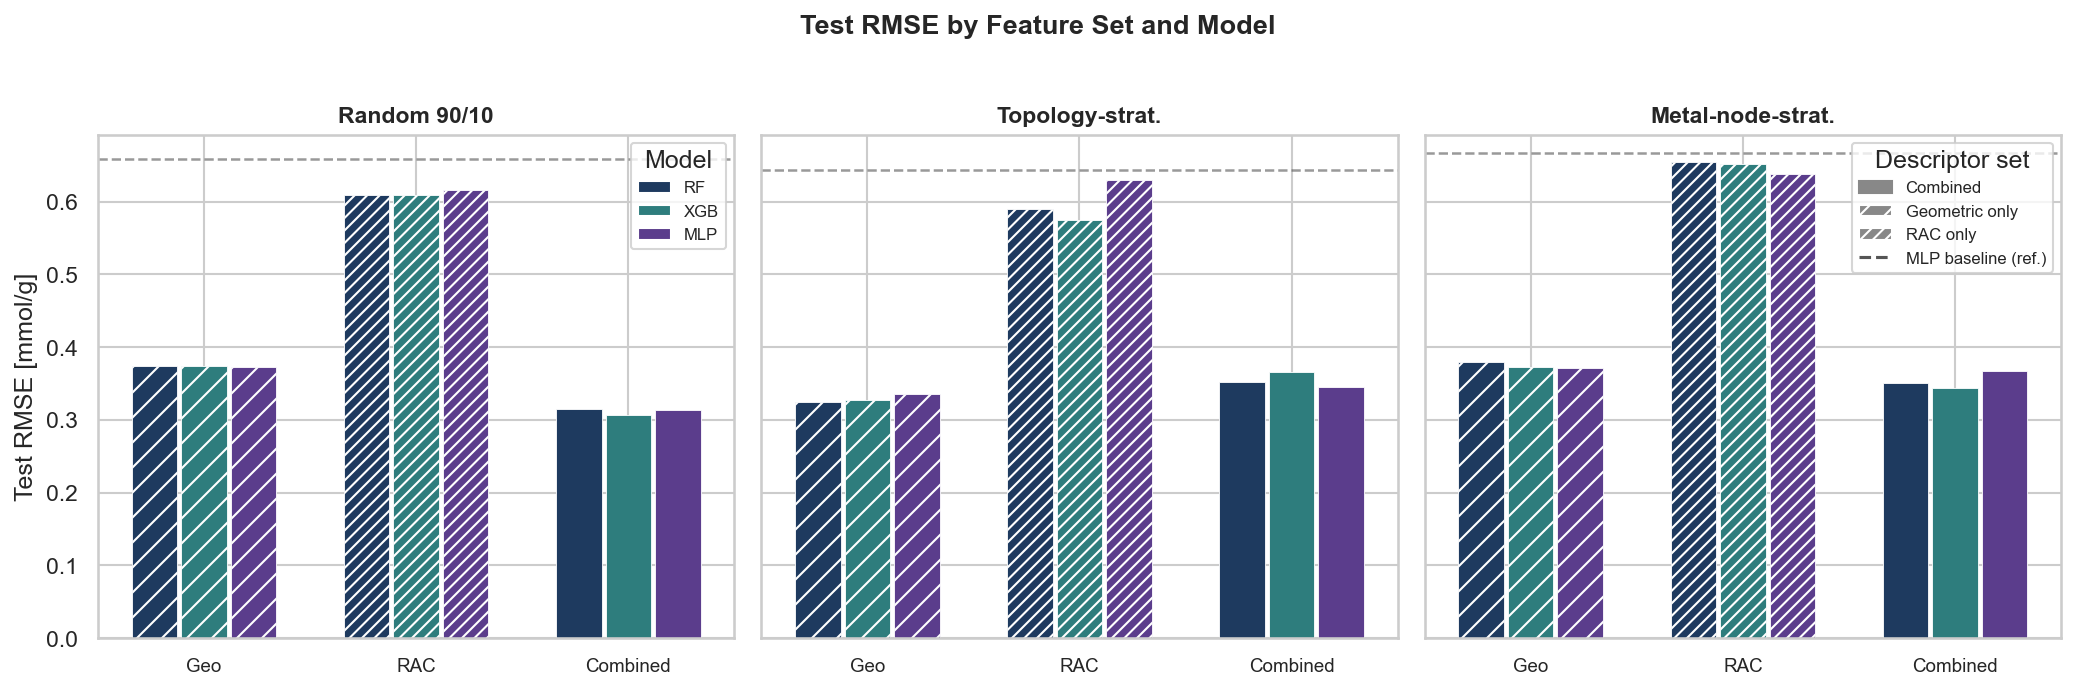

In [59]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)
fig.suptitle('Test RMSE by Feature Set and Model', fontsize=13, fontweight='bold', y=1.02)

for ax, split in zip(axes, SPLIT_ORDER):
    lookup = df[df['split'] == split].set_index(['feature_set', 'model'])['test_RMSE']

    for i, model in enumerate(MODEL_ORDER):
        offsets = X + (i - (N_MOD - 1) / 2) * BAR_W
        for k, feat in enumerate(FEATURE_ORDER):
            val   = lookup.get((feat, model), np.nan)
            hatch = HATCH_MAP[DESCRIPTOR_CAT[feat]]
            ax.bar(offsets[k], val, width=BAR_W * 0.92,
                   facecolor=MODEL_COLORS[model], hatch=hatch,
                   edgecolor='white', linewidth=0.4)

    # MLP baseline as single reference line
    bval = baseline_rmse.get(('MLP', split), np.nan)
    if not np.isnan(bval):
        ax.axhline(bval, color='#555555', lw=1.2, ls='--', alpha=0.6)

    ax.set_title(SPLIT_LABELS[split], fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Test RMSE [mmol/g]' if ax is axes[0] else '')
    ax.set_xticks(X)
    ax.set_xticklabels(FEATURE_LABELS, fontsize=9)
    ax.set_xlim(-0.5, N_FEAT - 0.5)

model_patches = [mpatches.Patch(facecolor=MODEL_COLORS[m], edgecolor='white', label=m)
                 for m in MODEL_ORDER]
desc_patches  = [
    mpatches.Patch(facecolor='#888', hatch='',     edgecolor='#888', label='Combined'),
    mpatches.Patch(facecolor='#888', hatch='//',   edgecolor='white', label='Geometric only'),
    mpatches.Patch(facecolor='#888', hatch='////', edgecolor='white', label='RAC only'),
    plt.Line2D([0], [0], color='#555555', lw=1.5, ls='--', label='MLP baseline (ref.)'),
]
axes[0].legend(handles=model_patches, title='Model',          loc='upper right', framealpha=0.8, fontsize=8)
axes[2].legend(handles=desc_patches,  title='Descriptor set', loc='upper right', framealpha=0.8, fontsize=8)

plt.tight_layout()
plt.savefig(f'{OUT}/model_comparison_rmse.png', bbox_inches='tight')
plt.show()

Generalisation: CV RMSE vs Test RMSE

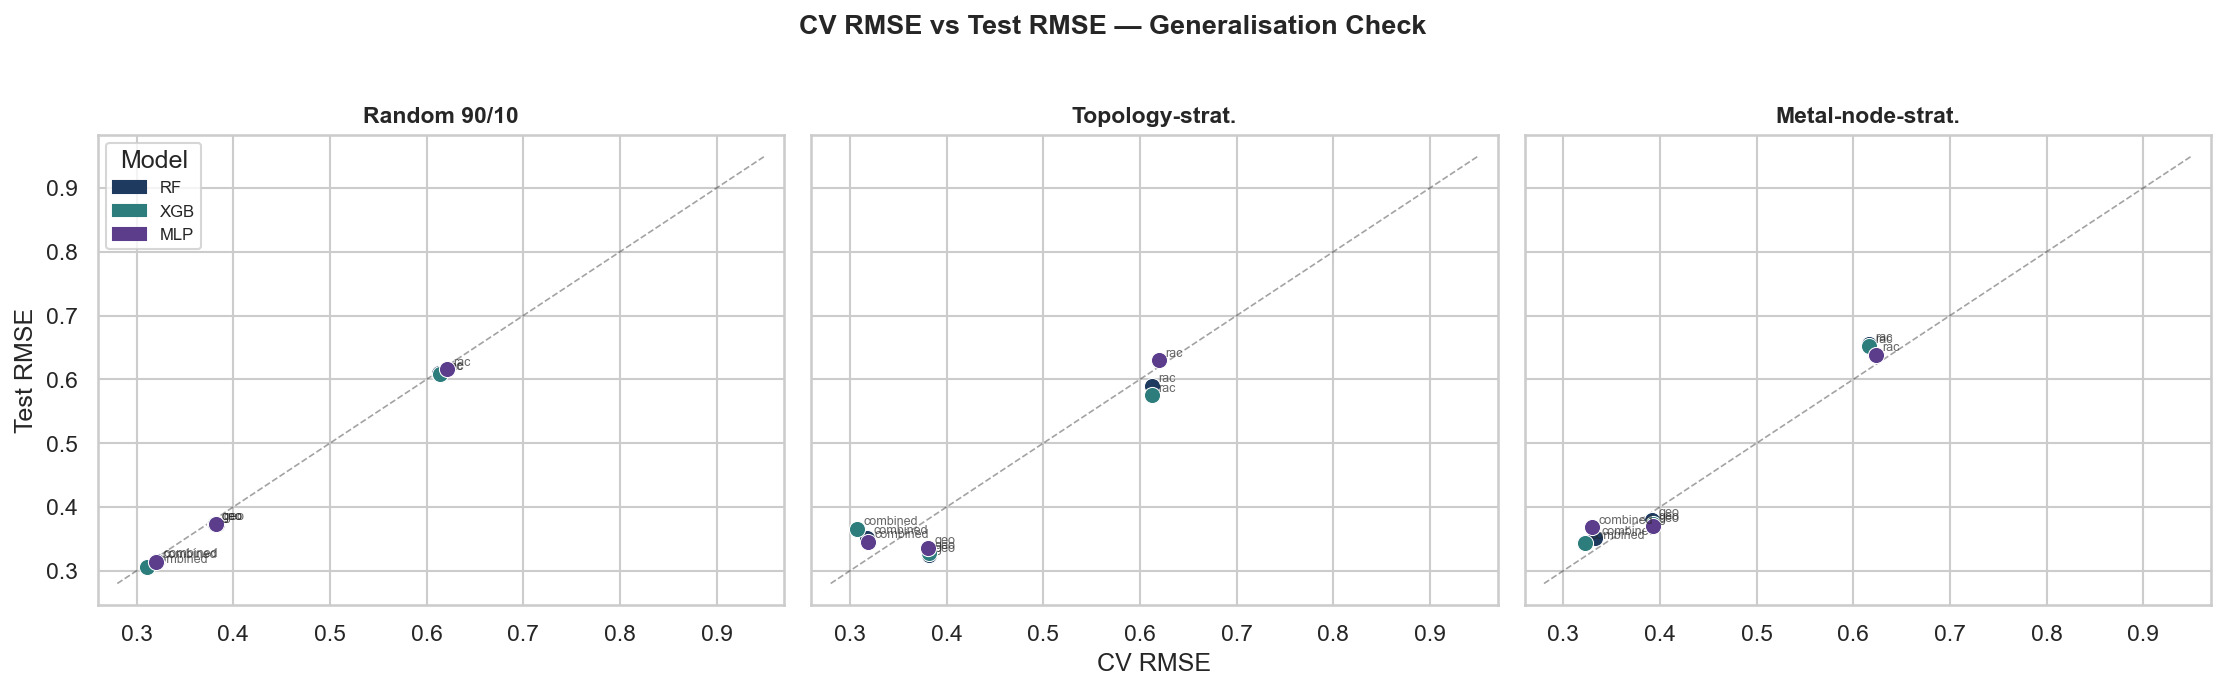

In [60]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True, sharex=True)
fig.suptitle('CV RMSE vs Test RMSE — Generalisation Check', fontsize=13, fontweight='bold', y=1.02)

lo, hi = 0.28, 0.95

for ax, split in zip(axes, SPLIT_ORDER):
    sub = df[df['split'] == split]
    for model in MODEL_ORDER:
        m = sub[sub['model'] == model]
        ax.scatter(m['best_cv_RMSE'], m['test_RMSE'],
                   color=MODEL_COLORS[model], s=60, zorder=3,
                   edgecolors='white', linewidths=0.5)
        for _, row in m.iterrows():
            short = str(row['feature_set']).replace('_all', '')
            ax.annotate(short, (row['best_cv_RMSE'], row['test_RMSE']),
                        fontsize=6, alpha=0.7, xytext=(3, 2), textcoords='offset points')

    ax.plot([lo, hi], [lo, hi], 'k--', lw=0.8, alpha=0.4)
    ax.set_title(SPLIT_LABELS[split], fontsize=11, fontweight='bold')
    ax.set_xlabel('CV RMSE' if ax is axes[1] else '')
    ax.set_ylabel('Test RMSE' if ax is axes[0] else '')
    ax.set_xlim(lo - 0.02, hi + 0.02)
    if ax is axes[0]:
        handles = [mpatches.Patch(color=MODEL_COLORS[m], label=m) for m in MODEL_ORDER]
        ax.legend(handles=handles, title='Model', fontsize=8, framealpha=0.8)

plt.tight_layout()
plt.savefig(f'{OUT}/model_comparison_generalisation.png', bbox_inches='tight')
plt.show()

Best R^2 per model and split (summary)

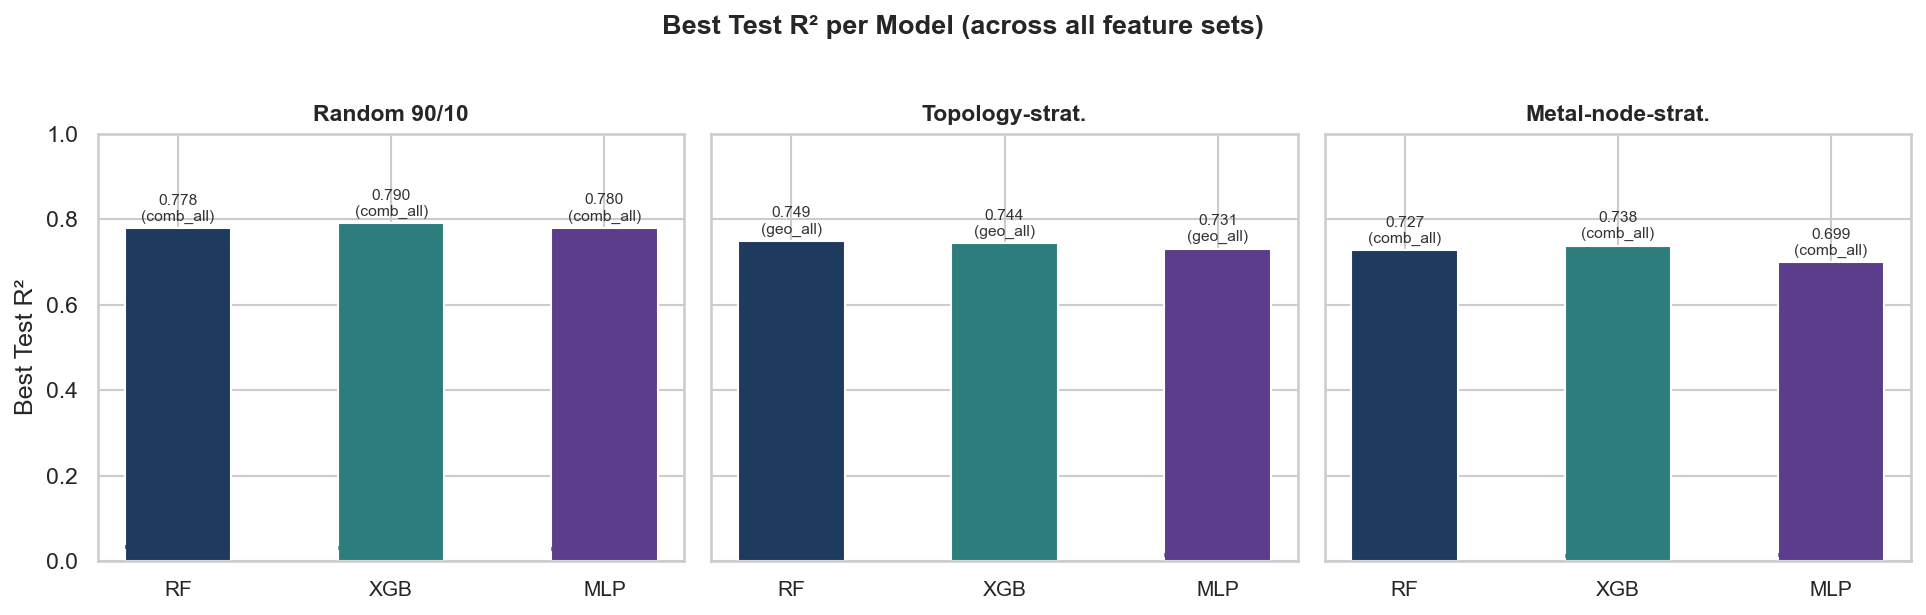

In [61]:
best = (
    df.groupby(['model', 'split'], observed=True)
      .agg(best_R2=('test_R2', 'max'), best_feature=('feature_set', lambda x: x.iloc[df.loc[x.index, 'test_R2'].argmax()]))
      .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
fig.suptitle('Best Test R² per Model (across all feature sets)', fontsize=13, fontweight='bold', y=1.02)

BAR_W_SINGLE = 0.5

for ax, split in zip(axes, SPLIT_ORDER):
    sub = best[best['split'] == split].sort_values('model').reset_index(drop=True)
    bars = ax.bar(
        sub['model'], sub['best_R2'],
        color=[MODEL_COLORS[m] for m in sub['model']],
        edgecolor='white', width=BAR_W_SINGLE
    )
    # baseline tick marks at each bar's baseline level
    for i, (_, row) in enumerate(sub.iterrows()):
        bval = baseline_r2.get((row['model'], split), np.nan)
        if not np.isnan(bval):
            ax.hlines(bval, i - BAR_W_SINGLE / 2, i + BAR_W_SINGLE / 2,
                      colors=MODEL_COLORS[row['model']], lw=2, ls='--', alpha=0.7)
    # value + feature set labels
    for bar, (_, row) in zip(bars, sub.iterrows()):
        feat_short = str(row['best_feature']).replace('combined_', 'comb_')
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{row['best_R2']:.3f}\n({feat_short})",
            ha='center', va='bottom', fontsize=7.5, color='#333333'
        )
    ax.set_title(SPLIT_LABELS[split], fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Best Test R²' if ax is axes[0] else '')
    ax.set_ylim(0, 1.0)
    ax.tick_params(axis='x', labelsize=10)

plt.tight_layout()
plt.savefig(f'{OUT}/model_comparison_best_r2.png', bbox_inches='tight')
plt.show()

Heatmap: R^2 across all conditions

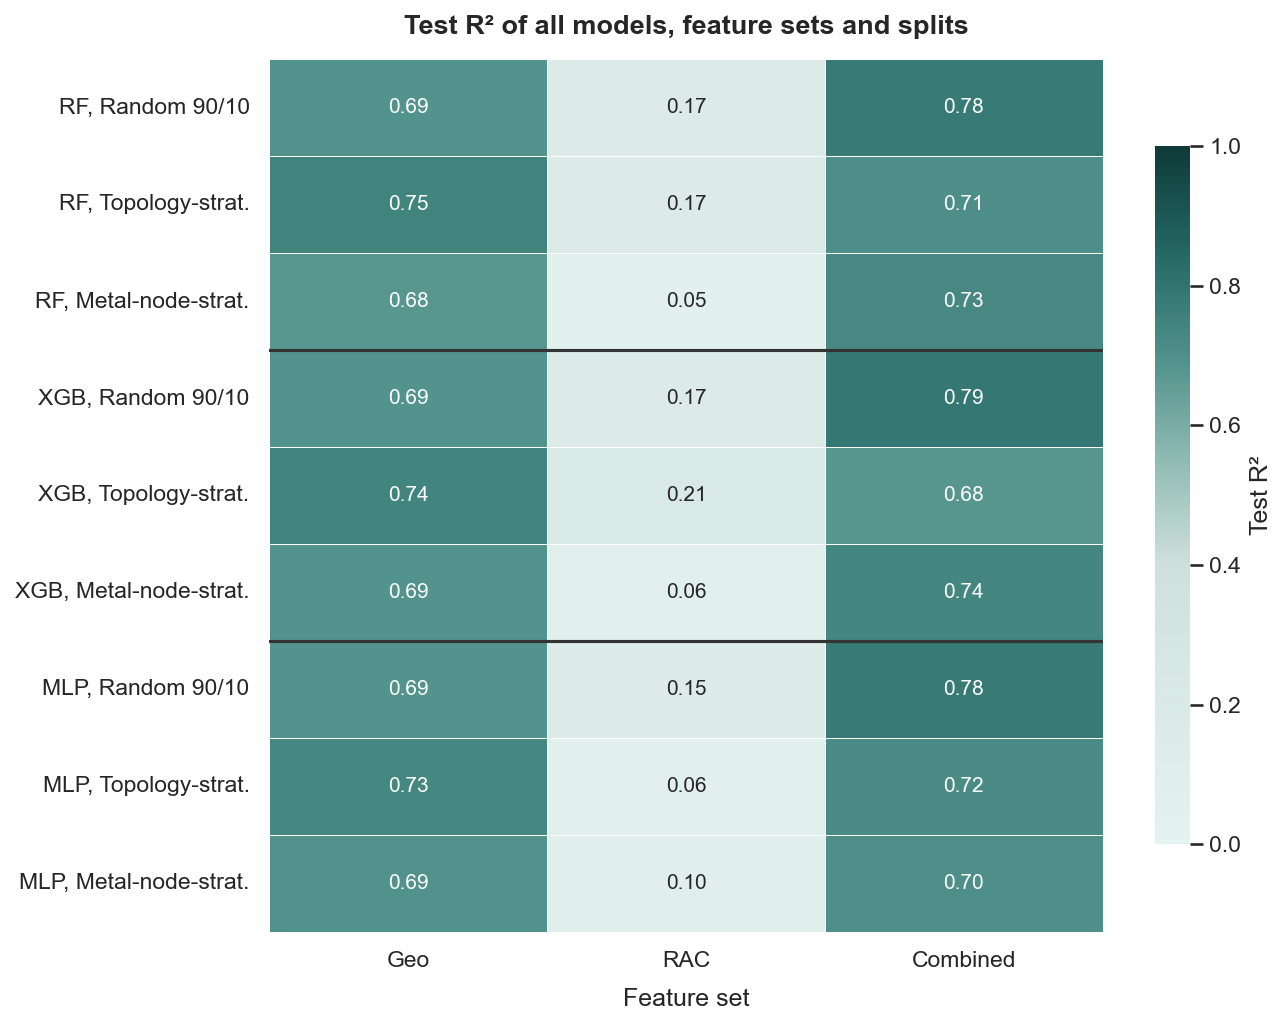

In [64]:
pivot = df.pivot_table(index=['model', 'split'], columns='feature_set', values='test_R2', observed=True)
pivot = pivot[FEATURE_ORDER]

idx_order = [(m, s) for m in MODEL_ORDER for s in SPLIT_ORDER]
pivot = pivot.loc[[(m, s) for m, s in idx_order if (m, s) in pivot.index]]

row_labels = [f'{m}, {SPLIT_LABELS[s]}' for m, s in pivot.index]

fig, ax = plt.subplots(figsize=(9, 7))

sns.heatmap(
    pivot, ax=ax,
    cmap=CMAP_R2, vmin=0.0, vmax=1.0,
    annot=True, fmt='.2f', annot_kws={'size': 10},
    linewidths=0.4, linecolor='white',
    xticklabels=FEATURE_LABELS,
    yticklabels=row_labels,
    cbar_kws={'label': 'Test R²', 'shrink': 0.8}
)

for y in [3, 6]:
    ax.axhline(y, color='#333333', lw=1.5)

ax.set_title('Test R² of all models, feature sets and splits',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Feature set', labelpad=8)
ax.set_ylabel('')
plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig(f'{OUT}/model_comparison_heatmap.png', bbox_inches='tight')
plt.show()